# 23CSE463 – Quantum Computing
## Worksheet 2: Implementation of Quantum Algorithms (Deutsch, Deutsch-Jozsa, Bernstein-Vazirani and Simon) Using Qiskit

**Name:** Agneay B Nair  
**Reg. No:** CH.SC.U4CSE24102  
**Ex. No:** 2

**Aim:** To implement the Deutsch, Deutsch-Jozsa, Bernstein-Vazirani and Simon algorithms in Qiskit, to construct the oracle for each, and to compare the number of oracle queries with the number a classical method needs.

### Setup

In [1]:
# Common setup for all programs in this worksheet
%matplotlib inline
import qiskit, numpy as np, matplotlib.pyplot as plt
from qiskit import QuantumCircuit, transpile
from qiskit.quantum_info import Statevector, Operator
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram
from IPython.display import display

print("Qiskit version:", qiskit.__version__)
sim = AerSimulator()
_seed = 2024                                      # seeds incremented per run -> reproducible counts
np.set_printoptions(precision=3, suppress=True, linewidth=110)
plt.rcParams["figure.dpi"] = 100

def show(fig):
    """display a matplotlib figure (circuit diagram / histogram) and close it"""
    display(fig); plt.close(fig)

def run(qc, shots=1024):
    global _seed
    _seed += 1
    return sim.run(transpile(qc, sim), shots=shots, seed_simulator=_seed).result().get_counts()

def amps(sv, tol=1e-9):
    """print the non-zero amplitudes of a statevector with Qiskit labels (qubit 0 rightmost)"""
    n = sv.num_qubits
    for i, a in enumerate(sv.data):
        if abs(a) > tol:
            print(f"  |{i:0{n}b}> : {a.real:+.3f}{a.imag:+.3f}j   P = {abs(a)**2:.3f}")


import itertools
REG_NO = "CH.SC.U4CSE24102"


Qiskit version: 2.5.2


### Program 1
Implement Deutsch\'s algorithm for all four one-bit functions: $f(x) = 0$, $f(x) = 1$, $f(x) = x$ and $f(x) = \text{NOT }x$. Show the circuit and the measurement for each, and classify each function as constant or balanced.

function     counts            result
f(x)=0       {'0': 1024}       constant


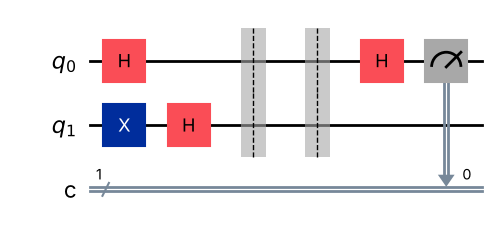

f(x)=1       {'0': 1024}       constant


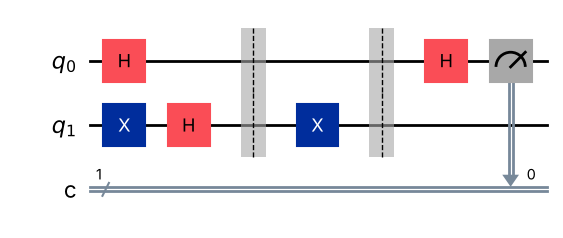

f(x)=x       {'1': 1024}       balanced


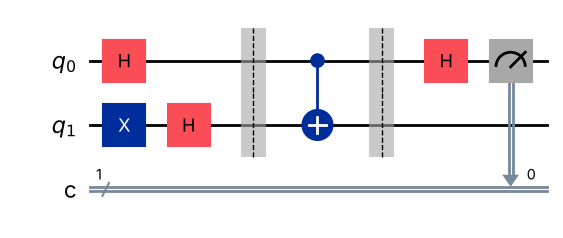

f(x)=NOT x   {'1': 1024}       balanced


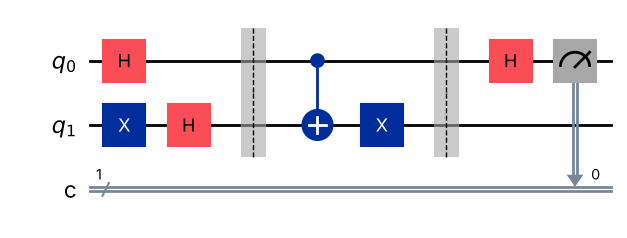

In [2]:
# Program 1: Deutsch's algorithm. q0 = input x, q1 = output y
def deutsch_oracle(kind):
    o = QuantumCircuit(2, name=f"Uf:{kind}")
    if kind == "f(x)=1":
        o.x(1)
    elif kind == "f(x)=x":
        o.cx(0, 1)
    elif kind == "f(x)=NOT x":
        o.cx(0, 1); o.x(1)
    return o                                  # f(x)=0 -> identity

def deutsch(kind):
    qc = QuantumCircuit(2, 1)
    qc.x(1); qc.h(1)                          # output qubit in |->
    qc.h(0)
    qc.barrier(); qc.compose(deutsch_oracle(kind), inplace=True); qc.barrier()
    qc.h(0)
    qc.measure(0, 0)
    return qc

print(f"{'function':<12} counts            result")
for kind in ["f(x)=0", "f(x)=1", "f(x)=x", "f(x)=NOT x"]:
    qc = deutsch(kind)
    c = run(qc)
    res = "constant" if list(c.keys()) == ["0"] else "balanced"
    print(f"{kind:<12} {str(c):<17} {res}")
    show(qc.draw("mpl"))

**Inference:** With one oracle query the input qubit reads 0 for the constant functions f(x)=0 and f(x)=1 and 1 for the balanced functions f(x)=x and f(x)=NOT x, in all 1024 shots. Classically two evaluations would be required.

### Program 2
Implement the Deutsch-Jozsa algorithm with three input qubits and a constant oracle. Show that the measurement is always 000.

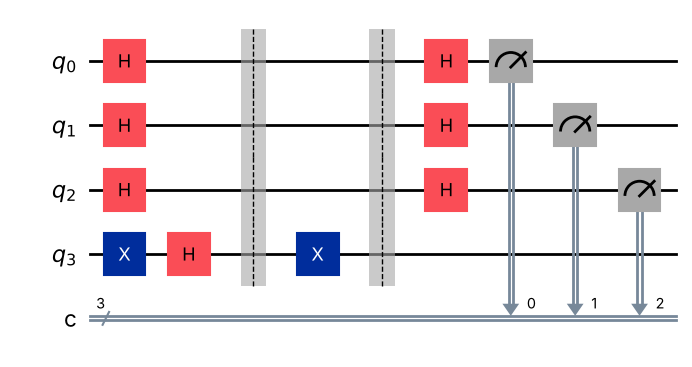

Counts: {'000': 1024}
Function is CONSTANT


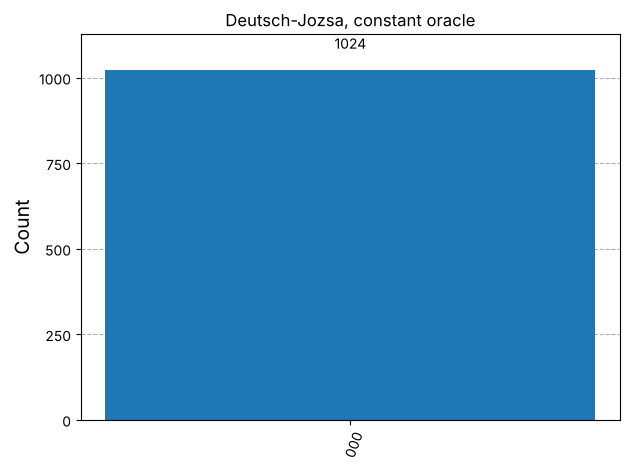

In [3]:
# Program 2: Deutsch-Jozsa, n = 3, constant oracle f(x) = 1
n = 3
qc = QuantumCircuit(n + 1, n)
qc.x(n); qc.h(n)
qc.h(range(n))
qc.barrier()
qc.x(n)                     # constant oracle: f(x) = 1 for every x
qc.barrier()
qc.h(range(n))
qc.measure(range(n), range(n))
show(qc.draw("mpl"))
counts = run(qc)
print("Counts:", counts)
print("Function is", "CONSTANT" if list(counts) == ["000"] else "BALANCED")
show(plot_histogram(counts, title="Deutsch-Jozsa, constant oracle"))

**Inference:** All 1024 shots give 000. A constant oracle only adds a global phase (−1)^f, so the final Hadamards return every input qubit to |0>; the amplitude of 000 is 1.

### Program 3
Implement the Deutsch-Jozsa algorithm with three input qubits and the balanced oracle $f(x) = x_{0} \oplus x_{1} \oplus x_{2}$. Plot the histogram and explain the result.

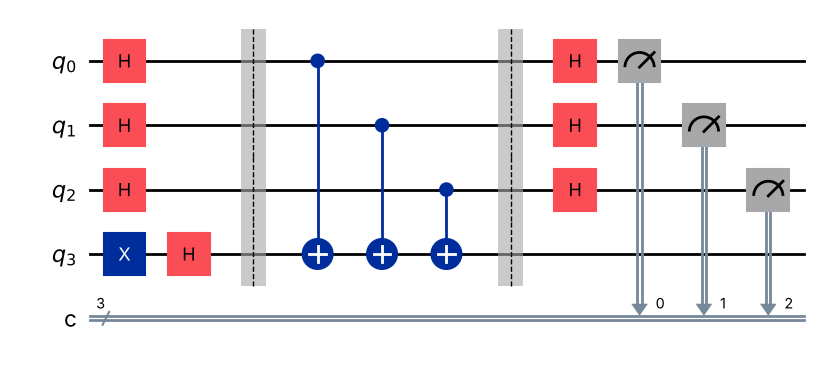

Counts: {'111': 1024}
Function is BALANCED


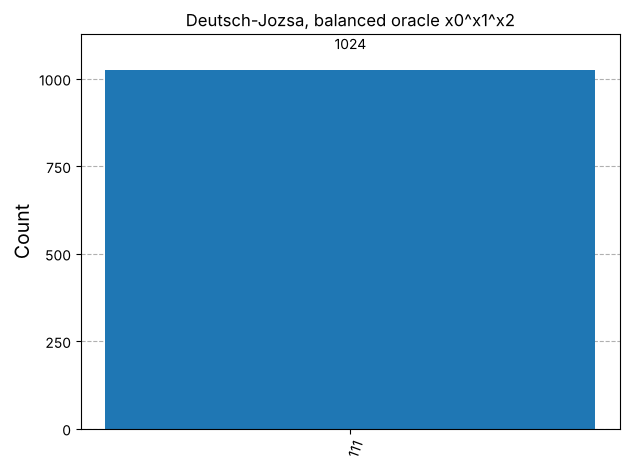

In [4]:
# Program 3: Deutsch-Jozsa, n = 3, balanced oracle f(x) = x0 xor x1 xor x2
n = 3
qc = QuantumCircuit(n + 1, n)
qc.x(n); qc.h(n)
qc.h(range(n))
qc.barrier()
for i in range(n):
    qc.cx(i, n)
qc.barrier()
qc.h(range(n))
qc.measure(range(n), range(n))
show(qc.draw("mpl"))
counts = run(qc)
print("Counts:", counts)
print("Function is", "CONSTANT" if list(counts) == ["000"] else "BALANCED")
show(plot_histogram(counts, title="Deutsch-Jozsa, balanced oracle x0^x1^x2"))

**Inference:** The result is always 111, never 000, so the function is balanced. Phase kickback gives (−1)^(x0⊕x1⊕x2)|x>, which the final Hadamards map to |111>; the amplitude of |000> is (1/8)Σ(−1)^f(x) = 0 for any balanced f.

### Program 4
Write a function that returns the Deutsch-Jozsa circuit for any number of input qubits and a chosen oracle type (constant or balanced). Test it for n = 2, 3 and 4.

 n   oracle      counts                   decision


 2   constant    {'00': 1024}             constant


 2   balanced    {'10': 1024}             balanced


 3   constant    {'000': 1024}            constant


 3   balanced    {'101': 1024}            balanced


 4   constant    {'0000': 1024}           constant
 4   balanced    {'0100': 1024}           balanced


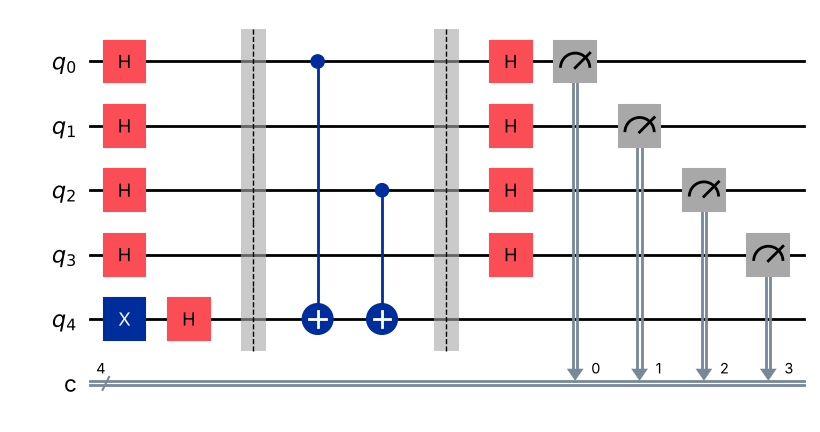

In [5]:
# Program 4: general Deutsch-Jozsa circuit generator
rng = np.random.default_rng(7)

def dj_oracle(n, kind):
    o = QuantumCircuit(n + 1, name=f"Uf:{kind}")
    if kind == "constant":
        if rng.integers(2):                   # f(x)=1 or f(x)=0 at random
            o.x(n)
    else:                                     # balanced: f(x) = b.x (+ optional NOT), b != 0
        b = rng.integers(1, 2**n)
        flip = rng.integers(2)
        for i in range(n):
            if (b >> i) & 1:
                o.cx(i, n)
        if flip:
            o.x(n)
    return o

def dj_circuit(n, kind):
    qc = QuantumCircuit(n + 1, n)
    qc.x(n); qc.h(n); qc.h(range(n)); qc.barrier()
    qc.compose(dj_oracle(n, kind), inplace=True)
    qc.barrier(); qc.h(range(n))
    qc.measure(range(n), range(n))
    return qc

print(" n   oracle      counts                   decision")
for n in [2, 3, 4]:
    for kind in ["constant", "balanced"]:
        qc = dj_circuit(n, kind)
        c = run(qc)
        dec = "constant" if list(c) == ["0" * n] else "balanced"
        print(f" {n}   {kind:<10}  {str(c):<24} {dec}")
show(dj_circuit(4, "balanced").draw("mpl"))

**Inference:** For n = 2, 3 and 4 the generator gives the correct answer every time: constant oracles always return the all-zero string and balanced oracles never do. One query suffices regardless of n.

### Program 5
Implement the Bernstein-Vazirani algorithm for the secret string s = 101. Verify that a single shot returns the secret string.

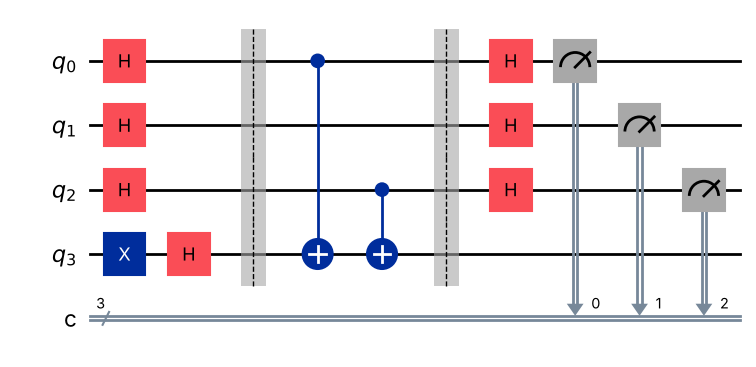

Single shot result: {'101': 1}
Recovered secret string: 101   correct: True
1024 shots: {'101': 1024}


In [6]:
# Program 5: Bernstein-Vazirani, s = 101
def bv_circuit(s):
    n = len(s)
    qc = QuantumCircuit(n + 1, n)
    qc.x(n); qc.h(n); qc.h(range(n)); qc.barrier()
    for i, bit in enumerate(reversed(s)):     # rightmost character -> qubit 0
        if bit == "1":
            qc.cx(i, n)
    qc.barrier(); qc.h(range(n))
    qc.measure(range(n), range(n))
    return qc

s = "101"
qc = bv_circuit(s)
show(qc.draw("mpl"))
one = run(qc, shots=1)
print("Single shot result:", one)
print("Recovered secret string:", list(one)[0], "  correct:", list(one)[0] == s)
print("1024 shots:", run(qc))

**Inference:** A single shot returns 101, the secret string itself. Phase kickback gives (−1)^(s·x)|x>, which is exactly H^⊗n|s>, so the final Hadamards produce |s> with probability 1. A classical method needs 3 queries.

### Program 6
Take the last two digits of your register number, find the remainder on division by 16 and write it as a 4-bit string. Use this as the secret string in the Bernstein-Vazirani algorithm and verify the result.

Register number: CH.SC.U4CSE24102  ->  last two digits = 02  ->  2 mod 16 = 2  ->  s = 0010


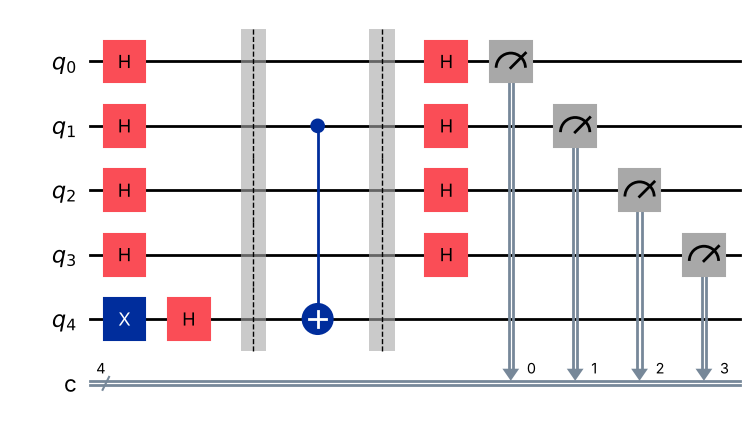

Counts: {'0010': 1024}
Recovered: 0010   correct: True


In [7]:
# Program 6: Bernstein-Vazirani with the register-number secret
last_two = int(REG_NO[-2:])
r = last_two % 16
s = format(r, "04b")
print(f"Register number: {REG_NO}  ->  last two digits = {last_two:02d}  ->  {last_two} mod 16 = {r}  ->  s = {s}")
qc = bv_circuit(s)
show(qc.draw("mpl"))
counts = run(qc)
print("Counts:", counts)
print("Recovered:", max(counts, key=counts.get), "  correct:", max(counts, key=counts.get) == s)

**Inference:** For register number CH.SC.U4CSE24102 the last two digits are 02, 02 mod 16 = 2, so s = 0010. The circuit returns 0010 in every shot with one oracle query (classically 4 queries).

### Program 7
Implement Simon\'s algorithm for n = 2 with the hidden string s = 11. One valid oracle copies the input register to the output register with CNOT gates and then, controlled on one input qubit where $s$ has a 1, applies CNOT gates to the output qubits where $s$ has a 1. Show that every measured string $z$ satisfies $z \cdot s = 0$ (mod 2).

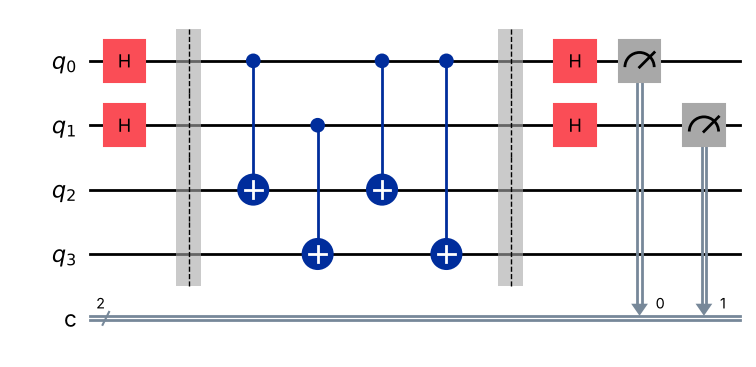

Counts: {'11': 511, '00': 513}
  z = 11:  z.s = 0 (mod 2)
  z = 00:  z.s = 0 (mod 2)


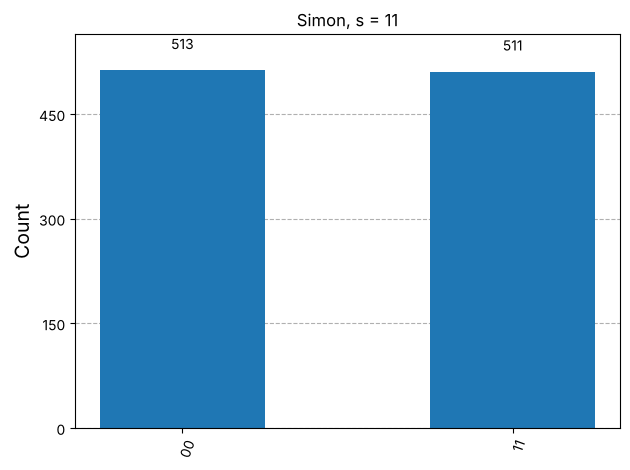

In [8]:
# Program 7: Simon's algorithm, n = 2, s = 11
def simon_oracle(s):
    n = len(s)
    o = QuantumCircuit(2 * n, name="Uf")
    for i in range(n):
        o.cx(i, n + i)                        # copy x -> output register
    sr = s[::-1]                              # sr[j] = bit on qubit j
    if "1" in sr:
        j = sr.index("1")                     # first input qubit where s has a 1
        for k in range(n):
            if sr[k] == "1":
                o.cx(j, n + k)
    return o

def simon_circuit(s):
    n = len(s)
    qc = QuantumCircuit(2 * n, n)
    qc.h(range(n)); qc.barrier()
    qc.compose(simon_oracle(s), inplace=True)
    qc.barrier(); qc.h(range(n))
    qc.measure(range(n), range(n))
    return qc

def dot(a, b):
    return sum(int(x) * int(y) for x, y in zip(a, b)) % 2

s = "11"
qc = simon_circuit(s)
show(qc.draw("mpl"))
counts = run(qc)
print("Counts:", counts)
for z in counts:
    print(f"  z = {z}:  z.s = {dot(z, s)} (mod 2)")
show(plot_histogram(counts, title="Simon, s = 11"))

**Inference:** Only z = 00 and z = 11 occur (≈50% each), and both satisfy z·s = 0 (mod 2). The non-trivial equation z = 11 gives s1 ⊕ s0 = 0, whose only non-zero solution is s = 11.

### Program 8
Implement Simon\'s algorithm for n = 3 with the hidden string s = 110. List the distinct measured strings and solve the equations $z \cdot s = 0$ by hand to recover $s$.

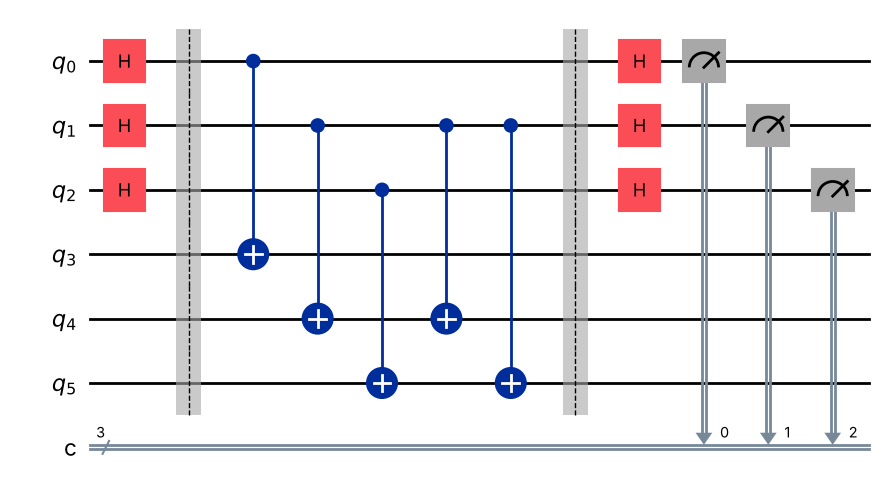

Counts: {'001': 264, '110': 256, '111': 259, '000': 245}
Distinct measured strings z and z.s:
  z = 000  ->  z.s = 0
  z = 001  ->  z.s = 0
  z = 110  ->  z.s = 0
  z = 111  ->  z.s = 0
Solutions of z.s = 0 for all z: ['110']


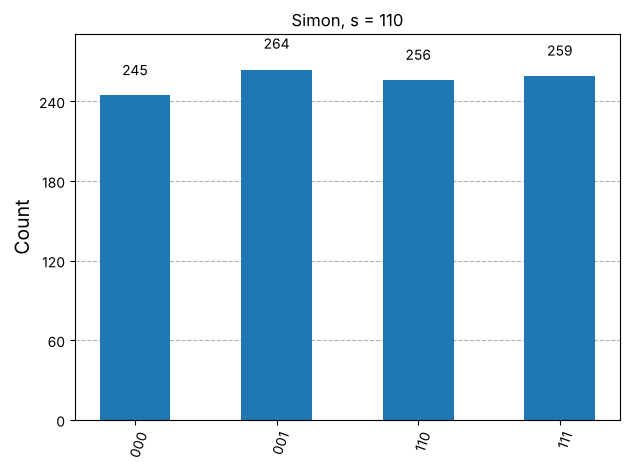

In [9]:
# Program 8: Simon's algorithm, n = 3, s = 110
s = "110"
qc = simon_circuit(s)
show(qc.draw("mpl"))
counts = run(qc)
print("Counts:", counts)
print("Distinct measured strings z and z.s:")
for z in sorted(counts):
    print(f"  z = {z}  ->  z.s = {dot(z, s)}")
# classical post-processing: non-zero s' orthogonal to every measured z
cands = [format(v, "03b") for v in range(1, 8)
         if all(dot(z, format(v, "03b")) == 0 for z in counts)]
print("Solutions of z.s = 0 for all z:", cands)
show(plot_histogram(counts, title="Simon, s = 110"))

**Inference:** Only 000, 001, 110 and 111 appear, each satisfying z·s = 0. By hand (s = s2 s1 s0): z = 001 gives s0 = 0; z = 110 gives s2 ⊕ s1 = 0; z = 111 gives s2 ⊕ s1 ⊕ s0 = 0. The only non-zero solution is s2 = s1 = 1, s0 = 0, i.e. s = 110.

### Program 9
Tabulate the number of oracle queries needed classically and with the quantum algorithm for Deutsch, Deutsch-Jozsa, Bernstein-Vazirani and Simon for n = 3, and comment on the comparison.

In [10]:
# Program 9: query comparison for n = 3
n = 3
rows = [
    ("Deutsch (n=1)",           "2",                     "1"),
    ("Deutsch-Jozsa",           f"2^(n-1)+1 = {2**(n-1)+1}", "1"),
    ("Bernstein-Vazirani",      f"n = {n}",              "1"),
    ("Simon",                   f"~2^(n/2) = {2**(n/2):.1f} (prob.), 2^(n-1)+1 = {2**(n-1)+1} (certain)", f"~n = {n} runs (O(n))"),
]
print(f"{'Algorithm':<20} | {'Classical queries':<48} | Quantum queries")
print("-" * 92)
for r in rows:
    print(f"{r[0]:<20} | {r[1]:<48} | {r[2]}")

Algorithm            | Classical queries                                | Quantum queries
--------------------------------------------------------------------------------------------
Deutsch (n=1)        | 2                                                | 1
Deutsch-Jozsa        | 2^(n-1)+1 = 5                                    | 1
Bernstein-Vazirani   | n = 3                                            | 1
Simon                | ~2^(n/2) = 2.8 (prob.), 2^(n-1)+1 = 5 (certain)  | ~n = 3 runs (O(n))


**Inference:** For n = 3 the quantum algorithms need 1 query (Deutsch, DJ, BV) or about n runs (Simon) against 2, 5, 3 and up to 5 classically. The gap is small at n = 3 but grows exponentially with n for Deutsch-Jozsa (exact) and Simon (even against randomised algorithms), and linearly for Bernstein-Vazirani.

## Viva Q&A

**1. What is a quantum oracle?**  
A quantum oracle is a black-box unitary that evaluates a function f reversibly, U_f|x>|y> = |x>|y⊕f(x)>, without revealing how f is computed. The cost of an algorithm is counted as the number of oracle calls (queries).

**2. What is phase kickback, and which state of the output qubit produces it?**  
When the output qubit is in |−> = (|0>−|1>)/√2, applying U_f leaves it unchanged and multiplies the input state by (−1)^f(x). The function value is 'kicked back' into the phase of the input register. It is produced by the |−> state of the output qubit.

**3. What is the difference between a constant function and a balanced function?**  
A constant function returns the same value for every input (all 0s or all 1s). A balanced function returns 0 for exactly half of the inputs and 1 for the other half.

**4. How many queries does a classical method need to solve the Deutsch-Jozsa problem with certainty for n input bits?**  
In the worst case 2^(n−1)+1 queries: a classical algorithm may see 2^(n−1) identical outputs from a balanced function before the next query decides.

**5. In the Deutsch-Jozsa algorithm, why does the result 00\...0 mean that the function is constant?**  
The amplitude of |00…0> after the final Hadamards is (1/2ⁿ)Σ(−1)^f(x). For a constant f this is ±1, so 00…0 is certain; for a balanced f the terms cancel to 0, so 00…0 never occurs.

**6. What problem does the Bernstein-Vazirani algorithm solve?**  
It finds a hidden n-bit string s, given an oracle for f(x) = s·x (mod 2), using a single query instead of n.

**7. Why can the Bernstein-Vazirani algorithm find the secret string in one query?**  
Phase kickback produces (1/√2ⁿ)Σ(−1)^(s·x)|x>, which is exactly H^⊗n|s>. Applying H^⊗n again gives |s> with certainty, so all n bits are obtained in one query by interference.

**8. State Simon\'s problem.**  
Given f: {0,1}ⁿ → {0,1}ⁿ with the promise that f(x) = f(y) if and only if y = x ⊕ s for a hidden string s, find s.

**9. Why does Simon\'s algorithm need several runs and classical post-processing?**  
Each run returns only one random string z with z·s = 0 (mod 2), which gives one linear equation. About n−1 linearly independent equations are needed, so the circuit is run about n times and the system is solved classically (Gaussian elimination over GF(2)).

**10. Is the Deutsch-Jozsa speed-up useful in practice? What happens if a small probability of error is allowed?**  
Not very: it is a speed-up only over deterministic classical algorithms that must be certain. If a small error is allowed, a classical algorithm that queries k random inputs fails with probability at most 2^(1−k), so a constant number of queries suffices. Its value is as a demonstration of superposition, phase kickback and interference.

## Result

The Deutsch, Deutsch-Jozsa, Bernstein-Vazirani and Simon algorithms were implemented in Qiskit with explicit oracles and simulated on AerSimulator. Deutsch and Deutsch-Jozsa classified constant and balanced functions with a single query, Bernstein-Vazirani recovered the secret strings 101 and 0010 (from register number CH.SC.U4CSE24102) in one query, and Simon's algorithm produced strings z with z·s = 0 from which s = 11 and s = 110 were recovered. The query comparison confirmed the quantum advantage. Hence the experiment was successfully completed.